# Smart Urban Waste Collection — ETA Model Training (v1)

**What this notebook does, in plain English:**

We're teaching a computer program (a "Random Forest" model) to guess how many minutes
until a garbage truck arrives at a street, based on things like: how far away it is,
how fast it's going, what time of day it is, and what kind of road it's on.

**Important — read this first:**

You currently have a *route assignment sheet* (which truck covers which streets, which
driver, which day) but you do **not yet have real GPS trip logs** (no real records of
"truck was here, then arrived there, and it took X minutes").

So in this notebook we do two things:
1. We use your **real** truck IDs, drivers and street names from your uploaded sheet.
2. We **generate synthetic (fake, clearly labeled) GPS trip data** shaped like what your
   real data will look like once your app is live and logging.

This lets you learn the entire process correctly now. Later, you literally just replace
the "generate synthetic data" cell with "load my real CSV of GPS logs" — nothing else
in this notebook needs to change. That cell is clearly marked below.

**Every result below is a demonstration on synthetic data, not a real accuracy claim.**


## Step 0: Setup

We import the tools we need:
- `pandas` / `numpy` — for handling data tables and numbers
- `matplotlib` — for simple charts
- `scikit-learn` — the machine learning library (has Random Forest built in)
- `joblib` — to save the trained model to a file


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
from pathlib import Path
from datetime import datetime, timedelta

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

Path("models").mkdir(exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

print("Setup complete.")


Setup complete.


## Step 1: Load your real route sheet

This is your actual uploaded file: truck IDs, drivers, and the streets each truck covers.
We'll use this as the *foundation* for realistic synthetic trips — real truck IDs and
real street names, not made-up ones.


In [2]:
routes_df = pd.read_excel("Truck_Data_Sheet.xlsx")
routes_df.columns = [c.strip() for c in routes_df.columns]
print(f"Loaded {len(routes_df)} route assignments.")
routes_df.head()


Loaded 119 route assignments.


,Specify Day,Driver Name,Truck-ID,Covering Areas
0,Monday,Asela,ZA-923-9236,"Kanaththa para,Galwala para,Gallage mawatha an..."
1,NaN,Vipula,ZB-0645,"Rajamaha Vihara road,Millagahawaththa road,Raj..."
2,NaN,Ruwan,LL-8825,"Rajamaha Vihara road for the Sanasa,Parakum Ro..."
3,NaN,Janaka,ZB-0646,all the narrow roads near the sanasa to pinniy...
4,NaN,Samantha,ZA9235,"Kurunda waththa road to pinniyara junction , m..."


In [3]:
# Basic cleanup: some Truck-ID values have inconsistent formatting (spaces, missing dashes).
# We standardize them here so the same truck isn't accidentally treated as two different trucks.

def clean_truck_id(x):
    if pd.isna(x):
        return None
    return str(x).strip().upper().replace(" ", "")

routes_df["truck_id_clean"] = routes_df["Truck-ID"].apply(clean_truck_id)

# A handful of rows list TWO ids in one cell (e.g. "ZA-9235, LL9690") or an id range
# (e.g. "ZA-923-9236"). We flag these rather than silently guessing which one is right.
multi_id_mask = routes_df["truck_id_clean"].str.contains(",", na=False)
print(f"Rows with multiple/ambiguous truck IDs (flagged, not auto-resolved): {multi_id_mask.sum()}")
routes_df.loc[multi_id_mask, ["Truck-ID", "Covering Areas"]]


Rows with multiple/ambiguous truck IDs (flagged, not auto-resolved): 0


,Truck-ID,Covering Areas


In [4]:
# Infer a simple road_type feature from the free-text area description.
# This is a heuristic (best-effort keyword search), not a guarantee — flagged as such.

def infer_road_type(text):
    if pd.isna(text):
        return "unknown"
    t = str(text).lower()
    has_main = "main road" in t
    has_narrow = "narrow" in t or "lane" in t or "by-road" in t or "by road" in t
    if has_main and has_narrow:
        return "mixed"
    if has_main:
        return "main_road"
    if has_narrow:
        return "narrow_road"
    return "unknown"

routes_df["road_type"] = routes_df["Covering Areas"].apply(infer_road_type)
routes_df["road_type"].value_counts()


road_type
narrow_road    66
unknown        43
mixed           8
main_road       2
Name: count, dtype: int64

## Step 2: Generate synthetic GPS trip data ⚠️ **(this is the cell you replace later with real data)**

**What's happening here:** for each real truck, we simulate several trips at different
times of day and days of the week. Each simulated trip has:

- `current_speed` — how fast the truck is going (km/h)
- `distance_to_target` — how far it is from the resident's street (km)
- `hour`, `day_of_week`, `is_weekend` — when the trip happens
- `road_type` — from your real route sheet
- `travel_time_minutes` — **the answer the model is trying to learn to predict**

We deliberately bake in realistic patterns — narrow roads and peak hours make trips
slower — so the model has real signal to learn from, the same way real GPS data would
have real signal. But it is still **synthetic, not observed data.**

When you have real GPS logs, replace this entire cell with something like:
```python
gps_df = pd.read_csv("data/raw/real_gps_logs.csv")
```
and skip straight to Step 3 (Data Validation).


In [5]:
# ===================== SYNTHETIC DATA GENERATION (clearly labeled) =====================

N_TRIPS_PER_TRUCK = 12          # simulate ~12 trips per truck
DAYS_SPAN = 42                  # spread across a 6-week period, like a real pilot would be
BASE_LAT, BASE_LON = 6.8500, 79.9000   # a generic reference point in the Colombo area (not exact real coordinates)

speed_by_road = {"main_road": (25, 45), "narrow_road": (8, 20), "mixed": (15, 30), "unknown": (15, 35)}

records = []
start_date = datetime(2026, 6, 1)

for _, row in routes_df.dropna(subset=["truck_id_clean"]).iterrows():
    truck_id = row["truck_id_clean"]
    road_type = row["road_type"]
    speed_lo, speed_hi = speed_by_road.get(road_type, (15, 35))

    for _ in range(N_TRIPS_PER_TRUCK):
        day_offset = np.random.randint(0, DAYS_SPAN)
        hour = np.random.choice(range(6, 17))  # collection hours: 6am - 5pm
        ts = start_date + timedelta(days=int(day_offset), hours=int(hour), minutes=int(np.random.randint(0, 60)))

        day_of_week = ts.weekday()  # 0=Monday
        is_weekend = int(day_of_week >= 5)
        is_peak = int(hour in [7, 8, 12, 13, 16])

        distance_km = round(np.random.uniform(0.2, 5.0), 2)
        speed_kmh = round(np.random.uniform(speed_lo, speed_hi) * (0.7 if is_peak else 1.0), 1)
        speed_kmh = max(speed_kmh, 3.0)

        # small random offsets so each trip has a slightly different lat/lon (still synthetic)
        current_lat = BASE_LAT + np.random.uniform(-0.03, 0.03)
        current_lon = BASE_LON + np.random.uniform(-0.03, 0.03)
        target_lat = current_lat + np.random.uniform(-0.01, 0.01)
        target_lon = current_lon + np.random.uniform(-0.01, 0.01)

        # ground-truth travel time: physics estimate + realistic noise + road/peak penalties
        base_minutes = (distance_km / speed_kmh) * 60
        road_penalty = {"main_road": 0, "narrow_road": 3, "mixed": 1.5, "unknown": 1}[road_type]
        peak_penalty = 4 if is_peak else 0
        noise = np.random.normal(0, 1.5)
        travel_time_minutes = max(1.0, round(base_minutes + road_penalty + peak_penalty + noise, 1))

        records.append({
            "vehicle_id": truck_id,
            "timestamp": ts,
            "current_lat": round(current_lat, 6),
            "current_lon": round(current_lon, 6),
            "target_lat": round(target_lat, 6),
            "target_lon": round(target_lon, 6),
            "current_speed_kmh": speed_kmh,
            "distance_to_target_km": distance_km,
            "road_type": road_type,
            "hour": hour,
            "day_of_week": day_of_week,
            "is_weekend": is_weekend,
            "travel_time_minutes": travel_time_minutes,
        })

gps_df = pd.DataFrame(records).sort_values("timestamp").reset_index(drop=True)
print(f"Generated {len(gps_df)} SYNTHETIC trip records for {gps_df['vehicle_id'].nunique()} trucks.")
gps_df.head()


Generated 1428 SYNTHETIC trip records for 29 trucks.


,vehicle_id,timestamp,current_lat,current_lon,target_lat,target_lon,current_speed_kmh,distance_to_target_km,road_type,hour,day_of_week,is_weekend,travel_time_minutes
0,LL-8825,2026-06-01 06:16:00,6.844487,79.923137,6.838925,79.927430,16.1,4.32,narrow_road,6,0,0,19.6
1,LL-7832,2026-06-01 06:21:00,6.877028,79.904897,6.875760,79.906499,11.4,4.36,narrow_road,6,0,0,27.1
2,ZB-0646,2026-06-01 06:24:00,6.838161,79.898065,6.833617,79.897336,31.6,2.35,unknown,6,0,0,5.3
3,226-6208,2026-06-01 07:02:00,6.847131,79.916473,6.841313,79.915536,10.5,0.68,narrow_road,7,0,0,12.0
4,ZA-9235,2026-06-01 08:10:00,6.822977,79.913476,6.815209,79.915642,7.6,2.36,narrow_road,8,0,0,28.2


## Step 3: Data validation

Before training on ANY data (synthetic or real), we check it for problems. A model
trained on bad data gives confidently wrong answers — so we never skip this step.

We check for:
- missing values in key columns
- impossible speeds (negative, or unrealistically high for a garbage truck)
- impossible coordinates
- negative or zero travel times
- duplicate rows


In [6]:
def validate_gps_data(df):
    issues = {}

    issues["missing_values"] = df[["vehicle_id", "current_speed_kmh", "distance_to_target_km",
                                     "travel_time_minutes"]].isna().sum().to_dict()

    issues["impossible_speed"] = int(((df["current_speed_kmh"] <= 0) | (df["current_speed_kmh"] > 80)).sum())
    issues["impossible_distance"] = int(((df["distance_to_target_km"] <= 0) | (df["distance_to_target_km"] > 50)).sum())
    issues["invalid_travel_time"] = int((df["travel_time_minutes"] <= 0).sum())
    issues["invalid_latitude"] = int(((df["current_lat"] < -90) | (df["current_lat"] > 90)).sum())
    issues["invalid_longitude"] = int(((df["current_lon"] < -180) | (df["current_lon"] > 180)).sum())
    issues["duplicate_rows"] = int(df.duplicated(subset=["vehicle_id", "timestamp"]).sum())

    return issues

validation_report = validate_gps_data(gps_df)
print(json.dumps(validation_report, indent=2))


{
  "missing_values": {
    "vehicle_id": 0,
    "current_speed_kmh": 0,
    "distance_to_target_km": 0,
    "travel_time_minutes": 0
  },
  "impossible_speed": 0,
  "impossible_distance": 0,
  "invalid_travel_time": 0,
  "invalid_latitude": 0,
  "invalid_longitude": 0,
  "duplicate_rows": 2
}


In [7]:
# If any issues were found, this is where we'd drop/fix them (never silently ignore them).
# Example pattern (kept generic so it also works once you plug in real data):

before = len(gps_df)

gps_df = gps_df[
    (gps_df["current_speed_kmh"] > 0) & (gps_df["current_speed_kmh"] <= 80) &
    (gps_df["distance_to_target_km"] > 0) & (gps_df["distance_to_target_km"] <= 50) &
    (gps_df["travel_time_minutes"] > 0)
].copy()

gps_df = gps_df.drop_duplicates(subset=["vehicle_id", "timestamp"])

after = len(gps_df)
print(f"Rows before cleaning: {before} | after cleaning: {after} | removed: {before - after}")


Rows before cleaning: 1428 | after cleaning: 1426 | removed: 2


## Step 4: Quick exploratory look (EDA)

Just enough charts to sanity-check the data makes sense before we train anything on it.


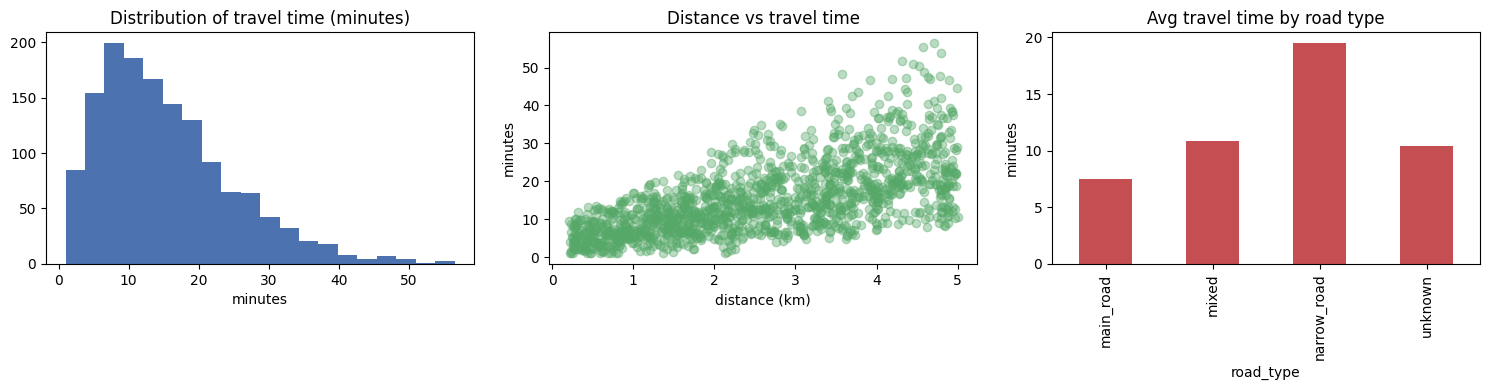

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(gps_df["travel_time_minutes"], bins=20, color="#4C72B0")
axes[0].set_title("Distribution of travel time (minutes)")
axes[0].set_xlabel("minutes")

axes[1].scatter(gps_df["distance_to_target_km"], gps_df["travel_time_minutes"], alpha=0.4, color="#55A868")
axes[1].set_title("Distance vs travel time")
axes[1].set_xlabel("distance (km)")
axes[1].set_ylabel("minutes")

gps_df.groupby("road_type")["travel_time_minutes"].mean().plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Avg travel time by road type")
axes[2].set_ylabel("minutes")

plt.tight_layout()
plt.show()


## Step 5: Feature engineering

We turn raw columns into the exact inputs the model will use. We wrap this in a
**function** so the exact same steps are used later when making live predictions —
this avoids a common, serious bug where training and prediction use slightly different
logic (called "training/serving skew").

Only features that would genuinely be known *before* the truck arrives are included
(no data leakage — we never use anything that secretly reveals the answer).


In [9]:
FEATURE_COLUMNS = [
    "distance_to_target_km",
    "current_speed_kmh",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "road_type_encoded",
]

ROAD_TYPE_MAP = {"main_road": 0, "mixed": 1, "narrow_road": 2, "unknown": 1}

def engineer_features(df):
    """Apply the SAME transformations at training time and prediction time."""
    df = df.copy()
    df["is_peak_hour"] = df["hour"].isin([7, 8, 12, 13, 16]).astype(int)
    df["road_type_encoded"] = df["road_type"].map(ROAD_TYPE_MAP).fillna(1).astype(int)
    return df

gps_df = engineer_features(gps_df)
gps_df[FEATURE_COLUMNS + ["travel_time_minutes"]].head()


,distance_to_target_km,current_speed_kmh,hour,day_of_week,is_weekend,is_peak_hour,road_type_encoded,travel_time_minutes
0,4.32,16.1,6,0,0,0,2,19.6
1,4.36,11.4,6,0,0,0,2,27.1
2,2.35,31.6,6,0,0,0,1,5.3
3,0.68,10.5,7,0,0,1,2,12.0
4,2.36,7.6,8,0,0,1,2,28.2


## Step 6: Split the data — chronologically, not randomly

**Why not just shuffle and split randomly?** Because GPS data is time-dependent. If we
let the model "see" trips from next week while training on this week, it's silently
cheating — in the real world, you'll never have future data available. So:

- **Earliest 70%** of trips (by date) → training
- **Next 15%** → validation (used to tune settings)
- **Most recent 15%** → test (final, honest check — touched only once)


In [10]:
gps_df = gps_df.sort_values("timestamp").reset_index(drop=True)

n = len(gps_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = gps_df.iloc[:train_end]
val_df = gps_df.iloc[train_end:val_end]
test_df = gps_df.iloc[val_end:]

print(f"Train: {len(train_df)}  ({train_df['timestamp'].min()} to {train_df['timestamp'].max()})")
print(f"Val:   {len(val_df)}  ({val_df['timestamp'].min()} to {val_df['timestamp'].max()})")
print(f"Test:  {len(test_df)}  ({test_df['timestamp'].min()} to {test_df['timestamp'].max()})")

X_train, y_train = train_df[FEATURE_COLUMNS], train_df["travel_time_minutes"]
X_val, y_val = val_df[FEATURE_COLUMNS], val_df["travel_time_minutes"]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df["travel_time_minutes"]


Train: 998  (2026-06-01 06:16:00 to 2026-06-29 07:11:00)
Val:   214  (2026-06-29 07:13:00 to 2026-07-05 07:52:00)
Test:  214  (2026-07-05 08:10:00 to 2026-07-12 16:38:00)


## Step 7: Baseline model (the "dumb but honest" comparison)

Before trusting Random Forest, we need proof it's actually better than a simple formula.
Our baseline: **travel time ≈ distance ÷ speed**, converted to minutes. No machine
learning at all — just physics.

If Random Forest can't beat this, it isn't earning its complexity.


In [11]:
def baseline_predict(df):
    return (df["distance_to_target_km"] / df["current_speed_kmh"]) * 60

baseline_test_pred = baseline_predict(test_df)

baseline_mae = mean_absolute_error(y_test, baseline_test_pred)
baseline_rmse = mean_squared_error(y_test, baseline_test_pred) ** 0.5
baseline_r2 = r2_score(y_test, baseline_test_pred)

print("Baseline (distance / speed formula) on TEST set:")
print(f"  MAE  = {baseline_mae:.2f} minutes")
print(f"  RMSE = {baseline_rmse:.2f} minutes")
print(f"  R2   = {baseline_r2:.3f}")


Baseline (distance / speed formula) on TEST set:
  MAE  = 4.15 minutes
  RMSE = 4.92 minutes
  R2   = 0.740


## Step 8: Train the Random Forest model

**What Random Forest actually is, simply:** it builds many decision trees (think:
lots of "if distance > X and it's rush hour, then roughly Y minutes" rules), each
trained on a slightly different random slice of the data, then averages their guesses.
Averaging many imperfect trees usually beats any single tree.

We try a small number of reasonable hyperparameter combinations and pick the best
using the **validation set** (never the test set — that stays untouched until the end).


In [12]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [2, 4, 8],
}

# Because our dataset is small, we use a simple manual search against the validation
# set rather than k-fold cross-validation on the training set (with 200-ish rows,
# folds would be too small to be meaningful).

best_score = None
best_params = None
best_model = None

from itertools import product

for n_estimators, max_depth, min_samples_leaf in product(
    param_grid["n_estimators"], param_grid["max_depth"], param_grid["min_samples_leaf"]
):
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=RANDOM_SEED,
    )
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_mae = mean_absolute_error(y_val, val_pred)

    if best_score is None or val_mae < best_score:
        best_score = val_mae
        best_params = dict(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        best_model = model

print("Best hyperparameters (lowest validation MAE):")
print(best_params)
print(f"Validation MAE with these settings: {best_score:.2f} minutes")


Best hyperparameters (lowest validation MAE):
{'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 2}
Validation MAE with these settings: 1.34 minutes


## Step 9: Evaluate honestly on the TEST set

This is the one true, untouched check. We report:

- **MAE (Mean Absolute Error):** on average, how many minutes off is the prediction?
  (If MAE = 3, predictions are typically off by about 3 minutes, in either direction.)
- **RMSE (Root Mean Square Error):** similar to MAE, but penalizes big mistakes more.
  If RMSE is much higher than MAE, it means a few predictions were way off.
- **R²:** how much of the variation in travel time the model explains (1.0 = perfect,
  0 = no better than always predicting the average).

We also compare directly against the baseline — the model only "earns its keep" if it
clearly beats the simple formula.


In [13]:
rf_test_pred = best_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_test_pred)
rf_rmse = mean_squared_error(y_test, rf_test_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_test_pred)

print("=== TEST SET RESULTS (synthetic data — not a real-world accuracy claim) ===\n")
print(f"{'Metric':<8}{'Baseline':>12}{'Random Forest':>16}")
print(f"{'MAE':<8}{baseline_mae:>12.2f}{rf_mae:>16.2f}")
print(f"{'RMSE':<8}{baseline_rmse:>12.2f}{rf_rmse:>16.2f}")
print(f"{'R2':<8}{baseline_r2:>12.3f}{rf_r2:>16.3f}")

improvement = (baseline_mae - rf_mae) / baseline_mae * 100
print(f"\nRandom Forest improves MAE over the baseline by {improvement:.1f}% (on synthetic data).")


=== TEST SET RESULTS (synthetic data — not a real-world accuracy claim) ===

Metric      Baseline   Random Forest
MAE             4.15            1.46
RMSE            4.92            1.83
R2             0.740           0.964

Random Forest improves MAE over the baseline by 64.8% (on synthetic data).


In [14]:
# Performance broken down by segment — never trust a single overall number.
test_results = test_df.copy()
test_results["predicted"] = rf_test_pred
test_results["abs_error"] = (test_results["predicted"] - test_results["travel_time_minutes"]).abs()

print("MAE by road type:")
print(test_results.groupby("road_type")["abs_error"].mean().round(2))

print("\nMAE by peak vs non-peak:")
print(test_results.groupby("is_peak_hour")["abs_error"].mean().round(2))

print("\nMAE by weekday vs weekend:")
print(test_results.groupby("is_weekend")["abs_error"].mean().round(2))


MAE by road type:
road_type
main_road      0.67
mixed          1.24
narrow_road    1.46
unknown        1.56
Name: abs_error, dtype: float64

MAE by peak vs non-peak:
is_peak_hour
0    1.40
1    1.54
Name: abs_error, dtype: float64

MAE by weekday vs weekend:
is_weekend
0    1.5
1    1.4
Name: abs_error, dtype: float64


## Step 10: Which features matter most?

This shows which inputs the model relies on most heavily. It tells us what the model
found *useful*, not what *causes* travel time — correlation, not causation.


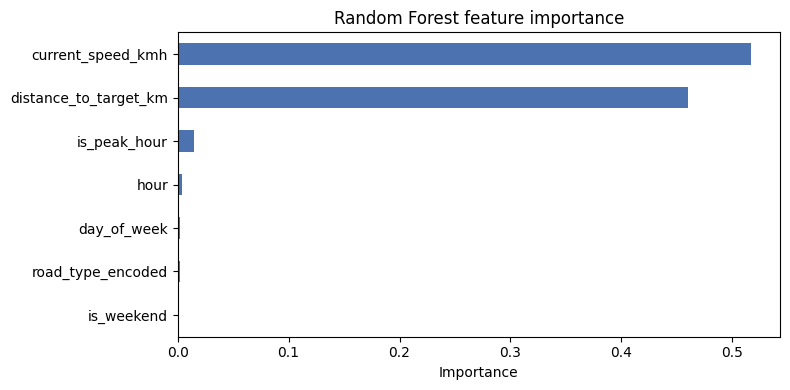

current_speed_kmh        0.517209
distance_to_target_km    0.459902
is_peak_hour             0.014831
hour                     0.003425
day_of_week              0.002349
road_type_encoded        0.001900
is_weekend               0.000384
dtype: float64

In [15]:
importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLUMNS).sort_values()

plt.figure(figsize=(8, 4))
importances.plot(kind="barh", color="#4C72B0")
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)


## Step 11: Save the model + metadata (versioned, never overwritten silently)

We save:
- the trained model file (`.joblib`)
- a metadata file recording exactly how it was trained, so `model_v1` is never confused
  with a future `model_v2` trained on different data


In [16]:
VERSION = "v1"
model_path = f"models/eta_model_{VERSION}.joblib"
metadata_path = f"models/eta_model_{VERSION}_metadata.json"

joblib.dump(best_model, model_path)

metadata = {
    "model_version": VERSION,
    "trained_on": "SYNTHETIC DATA — for pipeline development/demo only, not real-world accuracy",
    "training_date": datetime.now().isoformat(),
    "training_dataset_period": [str(train_df["timestamp"].min()), str(test_df["timestamp"].max())],
    "n_training_rows": len(train_df),
    "n_validation_rows": len(val_df),
    "n_test_rows": len(test_df),
    "feature_list": FEATURE_COLUMNS,
    "road_type_encoding": ROAD_TYPE_MAP,
    "hyperparameters": best_params,
    "random_seed": RANDOM_SEED,
    "test_mae_minutes": round(rf_mae, 2),
    "test_rmse_minutes": round(rf_rmse, 2),
    "test_r2": round(rf_r2, 3),
    "baseline_test_mae_minutes": round(baseline_mae, 2),
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved model to: {model_path}")
print(f"Saved metadata to: {metadata_path}")
print(json.dumps(metadata, indent=2))


Saved model to: models/eta_model_v1.joblib
Saved metadata to: models/eta_model_v1_metadata.json
{
  "model_version": "v1",
  "trained_on": "SYNTHETIC DATA \u2014 for pipeline development/demo only, not real-world accuracy",
  "training_date": "2026-09-27T18:48:18.559278",
  "training_dataset_period": [
    "2026-06-01 06:16:00",
    "2026-07-12 16:38:00"
  ],
  "n_training_rows": 998,
  "n_validation_rows": 214,
  "n_test_rows": 214,
  "feature_list": [
    "distance_to_target_km",
    "current_speed_kmh",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "road_type_encoded"
  ],
  "road_type_encoding": {
    "main_road": 0,
    "mixed": 1,
    "narrow_road": 2,
    "unknown": 1
  },
  "hyperparameters": {
    "n_estimators": 100,
    "max_depth": 8,
    "min_samples_leaf": 2
  },
  "random_seed": 42,
  "test_mae_minutes": 1.46,
  "test_rmse_minutes": 1.83,
  "test_r2": 0.964,
  "baseline_test_mae_minutes": 4.15
}


## Step 12: How to use this model to predict a NEW eta (example)

This is exactly the shape of function your FastAPI prediction service would call.
Notice it reuses `engineer_features()` from Step 5 — the same logic used in training,
so training and prediction never drift apart.


In [17]:
def predict_eta(raw_input: dict, model, feature_columns=FEATURE_COLUMNS):
    """raw_input: dict with keys distance_to_target_km, current_speed_kmh, hour,
    day_of_week, is_weekend, road_type"""
    df = pd.DataFrame([raw_input])
    df = engineer_features(df)
    pred_minutes = model.predict(df[feature_columns])[0]
    return round(float(pred_minutes), 1)

example_input = {
    "distance_to_target_km": 1.2,
    "current_speed_kmh": 18,
    "hour": 8,
    "day_of_week": 0,       # Monday
    "is_weekend": 0,
    "road_type": "narrow_road",
}

predicted_minutes = predict_eta(example_input, best_model)
print(f"Predicted travel time: {predicted_minutes} minutes")


Predicted travel time: 9.1 minutes


## What to do next (in order)

1. **Get your app logging real GPS pings and actual arrival times.** Even 2–4 weeks of
   real operation gives you a real dataset to replace the synthetic one.
2. Replace the Step 2 cell with `pd.read_csv("your_real_gps_logs.csv")`.
3. Re-run the notebook top to bottom exactly as-is — validation, cleaning, features,
   split, baseline, training, evaluation all stay the same.
4. Compare the **real** MAE/RMSE against this synthetic run — they will very likely
   differ, and that's expected and fine.
5. Once you have a real trained model you trust, this is `model_v1` for real. Any future
   retraining becomes `model_v2`, `model_v3`, etc. (never overwrite silently — see the
   metadata file pattern above).
6. Wrap `predict_eta()` in a small FastAPI endpoint so your Flutter app can call it.

If anything in this notebook is unclear, re-read the markdown cell right above the code
that's confusing — each one explains *why*, not just *what*.
